# Traffic Violations Insight System

# Table of Contents

1. [Introduction](#1-introduction)
   - [Problem Statement](#11-problem-statement)
   - [Business Use Cases](#12-business-use-cases)
   - [Project Objectives](#13-project-objectives)
2. [Import Required Libraries](#2-import-required-libraries)
3. [Load Data](#3-load-data)
   - [Load Excel Data](#31-load-excel-data)
   - [Convert To CSV](#32-convert-to-csv)
   - [Load CSV Data](#33-load-csv-data)
4. [Data Profiling](#4-data-profiling)
   - [Traffic Violations Dataset Overview](#41-traffic-violations-dataset-overview)
   - [Missing Values Summary](#42-missing-values-summary)
   - [Columns Profiling](#43-columns-profiling)
   - [Traffic Stop](#44-traffic-stop)
   - [Traffic Safety / Incident](#45-traffic-safety--incident)
   - [Driver / Vehicle Context](#46-driver--vehicle-context)
   - [Violation / Charge Table](#47-violation--charge-table)
   - [Search & Enforcement Columns](#48-search--enforcement-columns)
   - [Optional Visual Profiling](#49-optional-visual-profiling)
   

# 1. Introduction

### 1.1 Problem Statement

- Urban safety agencies generate millions of traffic violation records each year. 
- These datasets contain valuable information such as violation type, geographic location, driver demographics, vehicle details, and enforcement-related metadata. 
- However, the raw data is often noisy, inconsistent, duplicated, and difficult to interpret without proper preprocessing and analysis.
- In its raw form, such high-volume datasets cannot directly provide actionable insights for decision-making. Therefore, there is a need for a systematic approach to clean, preprocess, analyze, and visualize traffic violation data.
- The goal of this project is to develop a complete data analytics pipeline that transforms a large raw dataset of traffic violations (approximately 1 million records) into meaningful insights. 
- This will be achieved through:
    + Data Cleaning and Preprocessing
    + Exploratory Data Analysis (EDA)
    + An Interactive Visualization Dashboard built using Streamlit
- The system will allow users to explore traffic violation patterns, identify high-risk areas, and understand behavioral trends through interactive visual analytics.

### 1.2 Business Use Cases

- This project simulates real-world scenarios where organizations such as:
    + Departments of Transportation (DOT)
    + Police Departments
    + City Safety Authorities
    + Urban Planning Agencies
    + rely on large-scale traffic datasets to support operational and policy decisions.

- Key practical applications include:
    + Improving road safety by identifying high-risk violations and patterns
    + Detecting traffic violation hotspots across geographic areas
    + Optimizing patrol allocation based on incident density and trends
    + Identifying repeat offenders or high-risk driver groups
    + Supporting policy decisions related to traffic enforcement and public safety initiatives

### 1.3 Project Objectives

- The primary objective of this project is to transform a large raw dataset of traffic violations into a clean, structured, and analyzable dataset, and to generate meaningful insights through systematic analysis and visualization.

- The key objectives of this project include:
    1. Data Profiling
        + Examine the dataset to understand its structure and characteristics
        + Identify the number of records, columns, and data types
        + Analyze missing values across different variables
        + Detect duplicate records and inconsistencies
        + Explore unique values and distributions of categorical variables
        + Generate initial statistical summaries to assess data quality

    2. Data Cleaning
        + Identify and remove duplicate records
        + Handle missing or incomplete values appropriately
        + Standardize column names and formatting
        + Normalize categorical variables such as race, gender, vehicle make, and violation codes
        + Validate and clean geographic coordinates and temporal data
        + Detect and correct inconsistent or invalid entries

    3. Data Preprocessing
        + Convert columns to appropriate data types
        + Optimize dataset structure for efficient processing of large data volumes
        + Handle outliers and invalid values where necessary
        + Engineer additional features such as:
            * Time-of-day categories
            * Weekday vs weekend indicators
            * Violation frequency metrics

    4. Exploratory Data Analysis (EDA)
        + Identify the most common traffic violations
        + Analyze violation patterns across time (hour, day, month)
        + Examine geographic distribution of traffic incidents
        + Explore relationships between violations and driver demographics
        + Analyze vehicle-related trends such as frequently cited vehicle makes or models
        + Generate visualizations and statistical summaries to uncover meaningful insights

    5. Interactive Data Visualization
        + Develop an interactive dashboard using Streamlit
        + Allow users to filter data by:
            * Date
            * Location
            * Violation type
            * Vehicle type
            * Driver demographics
        + Provide visual insights through charts, distributions, and trend analysis
        + Display key metrics such as:
            * Total violations
            * Accident-related incidents
            * High-risk zones

# 2. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sqlalchemy import create_engine
import re
import plotly.express as px


In [2]:
# Make plots look nicer and all plots consistently
sns.set_theme(style="whitegrid")
#Show all columns in output
pd.set_option('display.max_columns',None)

# 3. Load Data

### 3.1 Load Excel Data

In [3]:
# Load dataset Traffic_Violations
#traffic_df=pd.read_excel("../data/Traffic_Violations.xlsx")

# Display First 5 Rows
#traffic_df.head()

### 3.2 Convert To CSV 

- Faster Loading
    + CSV files are plain text, so Pandas reads them much faster than .xlsx
    + A 1M-row CSV can load in seconds, whereas Excel might take minutes

- Lower Memory Overhead
    + Excel has extra formatting, styles, and metadata
    + CSV is simpler, so it uses less RAM

- Safer for Repeated Use
    + Once converted, no need to wait long every time when reload the dataset

In [4]:
#traffic_df.to_csv("../data/Traffic_Violations.csv",index=False)

### 3.3 Load CSV Data

In [5]:
traffic_df=pd.read_csv("../data/Traffic_Violations.csv")

# 4. Data Profiling

### 4.1 Traffic Violations Dataset Overview

- Check Dataset Shape

In [6]:
rows, cols = traffic_df.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 1048575, Columns: 43


- Shape: (1048575, 43) → ~1M rows, 43 columns

- Check the columns of the dataset

In [7]:
traffic_df.columns

Index(['SeqID', 'Date Of Stop', 'Time Of Stop', 'Agency', 'SubAgency',
       'Description', 'Location', 'Latitude', 'Longitude', 'Accident', 'Belts',
       'Personal Injury', 'Property Damage', 'Fatal', 'Commercial License',
       'HAZMAT', 'Commercial Vehicle', 'Alcohol', 'Work Zone',
       'Search Conducted', 'Search Disposition', 'Search Outcome',
       'Search Reason', 'Search Reason For Stop', 'Search Type',
       'Search Arrest Reason', 'State', 'VehicleType', 'Year', 'Make', 'Model',
       'Color', 'Violation Type', 'Charge', 'Article',
       'Contributed To Accident', 'Race', 'Gender', 'Driver City',
       'Driver State', 'DL State', 'Arrest Type', 'Geolocation'],
      dtype='object')

- Observations About Columns 



| Column Group             | Examples                                                                                                                                                    | Notes / Potential Use                                                                                       |
| ------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------- |
| **ID / Metadata**        | `SeqID`, `Agency`, `SubAgency`                                                                                                                              | Unique identifiers and enforcement agencies. Useful for grouping, filtering, or tracking duplicate records. |
| **Time / Date**          | `Date Of Stop`, `Time Of Stop`, `Year`                                                                                                                      | Important for **time-based analysis**, violation trends, and time-of-day feature engineering.               |
| **Location**             | `Location`, `Latitude`, `Longitude`, `State`, `Driver City`, `Driver State`, `Geolocation`                                                                  | Enables **geospatial analysis**, hotspot detection, and mapping violations.                                 |
| **Violation Info**       | `Description`, `Violation Type`, `Charge`, `Article`                                                                                                        | Core of the dataset; used for **categorical analysis** of violations.                                       |
| **Driver Info**          | `Race`, `Gender`                                                                                                                                            | Allows demographic analysis — e.g., which groups have specific violations.                                  |
| **Vehicle Info**         | `VehicleType`, `Make`, `Model`, `Color`, `Commercial Vehicle`, `HAZMAT`                                                                                     | Useful for vehicle-based trends or detecting high-risk vehicle types.                                       |
| **Safety / Incident**    | `Accident`, `Contributed To Accident`, `Personal Injury`, `Property Damage`, `Fatal`, `Belts`, `Alcohol`, `Work Zone`                                       | For **safety analysis**, accident patterns, and risk assessment.                                            |
| **Search / Enforcement** | `Search Conducted`, `Search Disposition`, `Search Outcome`, `Search Reason`, `Search Reason For Stop`, `Search Type`, `Search Arrest Reason`, `Arrest Type` | Useful for analyzing enforcement patterns, searches, and arrests.                                           |


- Column Name Cleanup

In [8]:
# Columns to keep readable with spaces
first_cols_readable = {
    'VehicleType': 'Vehicle Type',
    'SeqID': 'Seq ID',
    'SubAgency': 'Sub Agency'
}
traffic_df.rename(columns=first_cols_readable, inplace=True)
traffic_df.columns=[col.strip().replace(" ","_").lower() for col in traffic_df.columns]
traffic_df.columns

Index(['seq_id', 'date_of_stop', 'time_of_stop', 'agency', 'sub_agency',
       'description', 'location', 'latitude', 'longitude', 'accident', 'belts',
       'personal_injury', 'property_damage', 'fatal', 'commercial_license',
       'hazmat', 'commercial_vehicle', 'alcohol', 'work_zone',
       'search_conducted', 'search_disposition', 'search_outcome',
       'search_reason', 'search_reason_for_stop', 'search_type',
       'search_arrest_reason', 'state', 'vehicle_type', 'year', 'make',
       'model', 'color', 'violation_type', 'charge', 'article',
       'contributed_to_accident', 'race', 'gender', 'driver_city',
       'driver_state', 'dl_state', 'arrest_type', 'geolocation'],
      dtype='object')

- Column names were standardized to lowercase and underscores to ensure consistency and easier referencing during analysis.

In [9]:
traffic_df.dtypes

seq_id                      object
date_of_stop                object
time_of_stop                object
agency                      object
sub_agency                  object
description                 object
location                    object
latitude                   float64
longitude                  float64
accident                    object
belts                       object
personal_injury             object
property_damage             object
fatal                       object
commercial_license          object
hazmat                      object
commercial_vehicle          object
alcohol                     object
work_zone                   object
search_conducted            object
search_disposition          object
search_outcome              object
search_reason               object
search_reason_for_stop      object
search_type                 object
search_arrest_reason        object
state                       object
vehicle_type                object
year                

In [10]:
traffic_df.dtypes.value_counts()

object     39
float64     3
bool        1
Name: count, dtype: int64

- Data types:
    + object: 39
    + float64: 3
    + bool: 1
- Actionable note: 
    + Most columns are categorical and currently stored as object type. 
    + Binary indicator columns (e.g., accident, alcohol, belts) may be converted to categorical or boolean types during preprocessing to improve memory efficiency.

- Quick Info about the dataset

In [11]:
traffic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 43 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   seq_id                   1048575 non-null  object 
 1   date_of_stop             1048575 non-null  object 
 2   time_of_stop             1048575 non-null  object 
 3   agency                   1048575 non-null  object 
 4   sub_agency               1048575 non-null  object 
 5   description              1048566 non-null  object 
 6   location                 1048574 non-null  object 
 7   latitude                 1048575 non-null  float64
 8   longitude                1048575 non-null  float64
 9   accident                 1048575 non-null  object 
 10  belts                    1048575 non-null  object 
 11  personal_injury          1048575 non-null  object 
 12  property_damage          1048575 non-null  object 
 13  fatal                    1048575 non-null 

- Memory usage: 337 MB

### 4.2 Missing Values Summary

In [12]:
missing_summary=traffic_df.isnull().sum().sort_values(ascending=False)
missing_pct=(missing_summary/len(traffic_df)*100).round(2)
missing_df=pd.DataFrame({'Missing Count' : missing_summary,
                         'Missing %' : missing_pct})
print("==== Missing Values ===")
print(missing_df[missing_df['Missing Count']>0],'\n')

==== Missing Values ===
                        Missing Count  Missing %
search_arrest_reason           995840      94.97
search_type                    978599      93.33
search_reason                  978592      93.33
search_disposition             978592      93.33
search_outcome                 472821      45.09
search_reason_for_stop         453977      43.29
search_conducted               453740      43.27
color                           13772       1.31
article                          9892       0.94
year                             5700       0.54
dl_state                          819       0.08
driver_city                       170       0.02
model                              86       0.01
state                              50       0.00
make                               25       0.00
description                         9       0.00
driver_state                        8       0.00
location                            1       0.00 



##### Structural Missing Values (Expected Missing Data)
- These columns have missing values because they only apply when a search occurs.

| Column                 | Missing % |
| ---------------------- | --------- |
| search_arrest_reason   | 94.97%    |
| search_type            | 93.33%    |
| search_reason          | 93.33%    |
| search_disposition     | 93.33%    |
| search_outcome         | 45.09%    |
| search_reason_for_stop | 43.29%    |
| search_conducted       | 43.27%    |

- Why this happens
    + Most traffic stops do not involve a search.

Example:

| Search Conducted | Search Type |
| ---------------- | ----------- |
| No               | NaN         |
| No               | NaN         |
| Yes              | Vehicle     |


- So the missing values are mostly logical, not data errors.

##### Minor Missing Values (Normal Data Issues)

- These columns have small percentages of missing values.

| Column  | Missing % |
| ------- | --------- |
| color   | 1.31%     |
| article | 0.94%     |
| year    | 0.54%     |

Some records simply did not capture this information.

Example:
- Vehicle color not recorded
- Article code missing
- Vehicle year missing

##### Extremely Small Missing Values

- These are almost negligible.

| Column       | Missing % |
| ------------ | --------- |
| dl_state     | 0.08%     |
| driver_city  | 0.02%     |
| model        | 0.01%     |
| state        | ~0%       |
| make         | ~0%       |
| description  | ~0%       |
| driver_state | ~0%       |
| location     | ~0%       |

- These are normal real-world data imperfections.
- The dataset shows two types of missing data:
    + Logical Missing
        - Caused by process rules
        - Example:
            + Search columns when no search occurred

    + Data Quality Missing
        - Caused by human or system data entry
        - Example:
            + Missing vehicle color
            + Missing model

### 4.3 Columns Profiling

- View Summary Statistics
    + For numeric columns:

In [13]:
traffic_df.describe()

,latitude,longitude,year
count,1.048575e+06,1.048575e+06,1.042875e+06
mean,3.579037e+01,-7.061435e+01,2.006783e+03
std,1.086119e+01,2.142944e+01,9.153045e+01
min,0.000000e+00,-1.512560e+02,0.000000e+00
25%,3.901456e+01,-7.719348e+01,2.003000e+03
50%,3.906358e+01,-7.708428e+01,2.008000e+03
75%,3.913666e+01,-7.702526e+01,2.013000e+03
max,4.154316e+01,3.906444e+01,9.999000e+03


- Observation:
    + The 'year' column contains unrealistic values (e.g., 0 or 9999), which likely represent data entry errors or placeholder values. 
    + These will be addressed during the data cleaning stage.

In [14]:
numerical_cols=traffic_df.select_dtypes(include=['int64','float64']).columns.tolist()
if numerical_cols:
    outliers={}
    for col in numerical_cols:
        Q1=traffic_df[col].quantile(0.25)
        Q3=traffic_df[col].quantile(0.75)
        IQR=Q3-Q1
        outlier_rows=traffic_df[(traffic_df[col]<Q1-1.5*IQR) | (traffic_df[col]>Q3+1.5*IQR)]
        outliers[col]=len(outlier_rows)
    print("=== Numeric Outliers (based on IQR) ===")
    for k,v in outliers.items():
        print(f"{k}:{v} outliers")

=== Numeric Outliers (based on IQR) ===
latitude:89470 outliers
longitude:88822 outliers
year:4499 outliers


- View Summary Statistics
    + For categorical columns:

In [15]:
traffic_df.describe(include="O")

,seq_id,date_of_stop,time_of_stop,agency,sub_agency,description,location,accident,belts,personal_injury,property_damage,fatal,commercial_license,hazmat,commercial_vehicle,alcohol,work_zone,search_conducted,search_disposition,search_outcome,search_reason,search_reason_for_stop,search_type,search_arrest_reason,state,vehicle_type,make,model,color,violation_type,charge,article,race,gender,driver_city,driver_state,dl_state,arrest_type,geolocation
count,1048575,1048575,1048575,1048575,1048575,1048566,1048574,1048575,1048575,1048575,1048575,1048575,1048575,1048575,1048575,1048575,1048575,594835,69983,575754,69983,594598,69976,52735,1048525,1048575,1048550,1048489,1034803,1048575,1048575,1038683,1048575,1048575,1048405,1048567,1047756,1048575,1048575
unique,568057,4821,1440,1,9,11400,163985,2,2,2,2,2,2,2,2,2,2,2,7,5,9,707,6,8,69,32,3346,16805,26,4,1048,6,6,3,6373,64,70,19,484991
top,33c49de3-9e36-4f36-9326-b59a95e86fe8,05/20/2014,23:30:00,MCP,"4th District, Wheaton",DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC...,RT 28 @ BLACKBERRY DR,No,No,No,No,No,No,No,No,No,No,No,Nothing,Citation,Incident to Arrest,21-201(a1),Both,Stop,MD,02 - Automobile,HONDA,4S,BLACK,Citation,21-801.1,Transportation Article,WHITE,M,SILVER SPRING,MD,MD,A - Marked Patrol,"(0.0, 0.0)"
freq,59,760,1420,1048575,223650,70435,1474,998242,1007996,1025976,1009269,1048174,1016347,1048512,1045673,1046088,1048247,524852,31260,428401,46934,70497,52328,36753,902869,903541,117152,96253,220416,849082,171071,1032890,348788,728722,250215,951915,907619,785542,88414


### 4.4 Traffic Stop
- (seq_id, date_of_stop, time_of_stop, agency, sub_agency, location, latitude, longitude)

##### seq_id – Traffic Stop Identifier

In [16]:
traffic_df['seq_id'].value_counts()

seq_id
33c49de3-9e36-4f36-9326-b59a95e86fe8    59
6c64b741-3b7e-4658-9fed-fd5c3af27250    43
75f55258-401e-4a3d-87e6-ff9394acb877    43
28c5bfc1-5670-4751-be16-e1d83cda20f0    42
859768f4-bde0-427b-a60f-07b1e2aaadc4    40
                                        ..
0e485b29-3984-4575-af52-bcf54bc48bef     1
f687d4d1-bc92-4c3d-b2da-b806e3b1c704     1
43bd4b41-c61c-40c4-a9d7-b4beace2c04a     1
a464e5d9-5ffe-4547-81df-6d5ef1c9d48b     1
a3f36661-991f-48fb-8672-256ca1fb741a     1
Name: count, Length: 568057, dtype: int64

- Total unique seq_ids: 568,057
- Total rows: 1,048,575

In [17]:
traffic_df[traffic_df['seq_id']=='33c49de3-9e36-4f36-9326-b59a95e86fe8'].head(5)


,seq_id,date_of_stop,time_of_stop,agency,sub_agency,description,location,latitude,longitude,accident,belts,personal_injury,property_damage,fatal,commercial_license,hazmat,commercial_vehicle,alcohol,work_zone,search_conducted,search_disposition,search_outcome,search_reason,search_reason_for_stop,search_type,search_arrest_reason,state,vehicle_type,year,make,model,color,violation_type,charge,article,contributed_to_accident,race,gender,driver_city,driver_state,dl_state,arrest_type,geolocation
497704,33c49de3-9e36-4f36-9326-b59a95e86fe8,04/27/2017,14:36:00,MCP,"4th District, Wheaton",OPERATING UNREGISTERED MOTOR VEHICLE ON HIGHWAY,ARCOLA AT PARKER,39.148865,-77.223045,No,No,No,No,No,No,No,No,No,No,No,NaN,Citation,NaN,21-707(a),NaN,NaN,FL,02 - Automobile,2006.0,CHEV,MALIBU,GRAY,Citation,13-401(b1),Transportation Article,False,BLACK,M,SILVER SPRING,MD,MD,A - Marked Patrol,"(39.148865, -77.223045)"
518608,33c49de3-9e36-4f36-9326-b59a95e86fe8,04/27/2017,14:36:00,MCP,"4th District, Wheaton",EXCEEDING POSTED MAXIMUM SPEED LIMIT: 53 MPH I...,ARCOLA AT PARKER,39.148865,-77.223045,Yes,No,No,No,No,No,No,No,No,No,No,NaN,Citation,NaN,21-707(a),NaN,NaN,FL,02 - Automobile,2006.0,CHEV,MALIBU,GRAY,Citation,21-801.1,Transportation Article,True,BLACK,M,SILVER SPRING,MD,MD,A - Marked Patrol,"(39.148865, -77.223045)"
534999,33c49de3-9e36-4f36-9326-b59a95e86fe8,04/27/2017,14:36:00,MCP,"4th District, Wheaton",PERSON DRIVING MOTOR VEHICLE ON HIGHWAY OR PUB...,ARCOLA AT PARKER,39.148865,-77.223045,No,No,No,No,No,No,No,No,No,No,No,NaN,Citation,NaN,21-707(a),NaN,NaN,FL,02 - Automobile,2006.0,CHEV,MALIBU,GRAY,Citation,16-303(c),Transportation Article,False,BLACK,M,SILVER SPRING,MD,MD,A - Marked Patrol,"(39.148865, -77.223045)"
539321,33c49de3-9e36-4f36-9326-b59a95e86fe8,04/27/2017,14:36:00,MCP,"4th District, Wheaton",DRIVING VEHICLE ON HIGHWAY WITH SUSPENDED REGI...,ARCOLA AT PARKER,39.148865,-77.223045,No,No,No,No,No,No,No,No,No,No,No,NaN,Citation,NaN,21-707(a),NaN,NaN,FL,02 - Automobile,2006.0,CHEV,MALIBU,GRAY,Citation,13-401(h),Transportation Article,False,BLACK,M,SILVER SPRING,MD,MD,A - Marked Patrol,"(39.148865, -77.223045)"
539405,33c49de3-9e36-4f36-9326-b59a95e86fe8,04/27/2017,14:36:00,MCP,"4th District, Wheaton",DRIVER CHANGING LANES WHEN UNSAFE,ARCOLA AT PARKER,39.148865,-77.223045,Yes,No,No,No,No,No,No,No,No,No,No,NaN,Citation,NaN,21-707(a),NaN,NaN,FL,02 - Automobile,2006.0,CHEV,MALIBU,GRAY,Citation,21-309(b),Transportation Article,True,BLACK,M,SILVER SPRING,MD,MD,A - Marked Patrol,"(39.148865, -77.223045)"


In [18]:
traffic_df[traffic_df['seq_id']=='33c49de3-9e36-4f36-9326-b59a95e86fe8'][['description','charge']].drop_duplicates()

,description,charge
497704,OPERATING UNREGISTERED MOTOR VEHICLE ON HIGHWAY,13-401(b1)
518608,EXCEEDING POSTED MAXIMUM SPEED LIMIT: 53 MPH I...,21-801.1
534999,PERSON DRIVING MOTOR VEHICLE ON HIGHWAY OR PUB...,16-303(c)
539321,DRIVING VEHICLE ON HIGHWAY WITH SUSPENDED REGI...,13-401(h)
539405,DRIVER CHANGING LANES WHEN UNSAFE,21-309(b)
539607,DRIVER FAILURE TO STOP AT STEADY CIRCULAR RED ...,21-202(h1)
542204,DRIVING VEHICLE IN EXCESS OF REASONABLE AND PR...,21-801(a)
545859,DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC...,21-201(a1)
552444,FAILURE TO CONTROL VEHICLE SPEED ON HIGHWAY TO...,21-801(b)
558654,DRIVER FAILURE TO STOP AT STOP SIGN LINE,21-707(a)


- This shows that one traffic stop can have multiple charges/violations.
- Removing description and charge and checking duplicates shows:

In [19]:
traffic_df[traffic_df['seq_id']=='33c49de3-9e36-4f36-9326-b59a95e86fe8'] \
.drop(columns=['description','charge']) \
.duplicated().sum()

np.int64(57)

- There are no duplicate rows beyond different charges, meaning each row is unique at the charge-level.

- Insights & Implications:
    + The dataset is charge-level, not stop-level.
    + A single traffic stop can produce multiple rows if multiple violations occur.
    - For analysis, consider:
        + Stop-level dataset – aggregate rows by seq_id to get one row per stop.
        + Charge-level dataset – keep as-is to analyze violation-level patterns.

##### Date Of Stop - Traffic Stop 

In [20]:
traffic_df['date_of_stop'].describe()

count        1048575
unique          4821
top       05/20/2014
freq             760
Name: date_of_stop, dtype: object

- Insights & Implications:
    + No null values – all rows have a recorded stop date.
    + Currently stored as string/object type → needs conversion to datetime for proper analysis.
    + Feature engineering, e.g.,
        - Day of week (Monday, Tuesday, …)
        - Weekday vs weekend
        - Month or year aggregation
    + Converting will enable:
        - Time-based trend analysis (daily, monthly, yearly patterns)
        - Detection of any invalid or out-of-range dates.
    + Date conversion will be performed in the Data Cleaning step.

##### Time of Stop - Traffic Stop

In [21]:
traffic_df['time_of_stop'].describe()

count      1048575
unique        1440
top       23:30:00
freq          1420
Name: time_of_stop, dtype: object

- Insights & Implications:
    + Data type: Currently stored as string/object → needs conversion to datetime/time for proper analysis.
    + Feature engineering opportunities:
        - Extract hour of day → identify peak violation hours.
        - Create time-of-day categories: Morning / Afternoon / Evening / Night.
        - Combine with date_of_stop → full timestamp for time-series analysis.
    + Missing / invalid values: None reported in profiling.
    + Visualization ideas:
        - Plot hourly violation distribution to see peak traffic stop times.
        - Combine with violation_type → understand which violations occur at which times.

##### Agency - Traffic Stop

In [22]:
traffic_df['agency'].value_counts()

agency
MCP    1048575
Name: count, dtype: int64

- Only 1 unique value in the dataset: MCP (Maryland State Police).
- This means all traffic stops in this dataset are handled by the same agency.

- Insights & Implications:
    + Low informational value:
        - Since there’s only one agency, this column does not help differentiate traffic stops.
        - Can be dropped for modeling or visual analysis, unless used for labeling in a multi-agency dataset in the future.
    + Related column – sub_agency:
        - sub_agency has 9 unique values, representing districts or units under MCP.
        - Combining agency + sub_agency into a single column can give a meaningful identifier for the enforcement unit, e.g., MCP – 4th District, Wheaton.
    + Feature engineering suggestion:
        - Create a new column:
            + traffic_df['full_agency'] = traffic_df['agency'] + " - " + traffic_df['sub_agency']
        - This can be used for grouping stops, mapping hotspots, or analyzing sub-agency trends.
        

##### Sub Agency - Traffic Stop

In [23]:
traffic_df['sub_agency'].value_counts()

sub_agency
4th District, Wheaton                              223650
3rd District, Silver Spring                        192627
2nd District, Bethesda                             166680
5th District, Germantown                           140466
6th District, Gaithersburg / Montgomery Village    116567
1st District, Rockville                            116083
Headquarters and Special Operations                 92500
W15                                                     1
S15                                                     1
Name: count, dtype: int64

- 9 unique sub-agencies in total.
- Majority of stops are handled by districts 1–6 and Headquarters/Special Operations.
- A couple of rare entries (W15, S15) appear only once each — likely data entry errors.

- Insights & Implications:
    + High-cardinality, but limited → can be used for district-level analysis or mapping violation hotspots.
    + Rare / invalid entries (W15, S15) → can be cleaned or grouped into Other.
    + Combine with agency → create full_agency for a complete identifier:
        - traffic_df['full_agency'] = traffic_df['agency'] + " - " + traffic_df['sub_agency']
        - Example: MCP - 4th District, Wheaton
    + Useful for visualizations, grouping, and trend analysis.
    + Potential Insights:
        - Which district reports most violations?
        - Are there district-level patterns in violation types, time, or demographics?
        - Can help allocate resources or patrol vehicles efficiently.

##### Location– Traffic Stop 
- (location, latitude, longitude, geolocation )

In [24]:

# 1. Location (Categorical)

location_summary = traffic_df['location'].describe()
print("=== Location Column Summary ===")
print(location_summary)
print("\nMissing Values:", traffic_df['location'].isnull().sum())


=== Location Column Summary ===
count                   1048574
unique                   163985
top       RT 28 @ BLACKBERRY DR
freq                       1474
Name: location, dtype: object

Missing Values: 1


- Insights & implications
    + location has one missing value out of ~1M rows (~0.0001%).
    + This row can be safely removed or ignored in geospatial analysis.
    + Impute location → only if you have other clues (like latitude/longitude, sub-agency)

In [25]:

# 2. Latitude and Longitude (Numeric)

coord_summary = traffic_df[['latitude','longitude']].describe()
print("=== Latitude & Longitude Summary ===")
print(coord_summary)


=== Latitude & Longitude Summary ===
           latitude     longitude
count  1.048575e+06  1.048575e+06
mean   3.579037e+01 -7.061435e+01
std    1.086119e+01  2.142944e+01
min    0.000000e+00 -1.512560e+02
25%    3.901456e+01 -7.719348e+01
50%    3.906358e+01 -7.708428e+01
75%    3.913666e+01 -7.702526e+01
max    4.154316e+01  3.906444e+01


In [26]:
# Define US / Maryland valid ranges
valid_lat_range = (24, 42)
valid_lon_range = (-125, -65)

# Filter invalid coordinates
invalid_coords = traffic_df[(traffic_df['latitude']==0) |
                            (traffic_df['longitude']==0) |
                            (traffic_df['latitude'] < valid_lat_range[0]) |
                            (traffic_df['latitude'] > valid_lat_range[1]) |
                            (traffic_df['longitude'] < valid_lon_range[0]) |
                            (traffic_df['longitude'] > valid_lon_range[1])]

invalid_coords[['location','latitude','longitude','sub_agency']].head()

,location,latitude,longitude,sub_agency
0,BRIGGS CHANEY RD @ COLUMIBA PIKE,0.0,0.0,"3rd District, Silver Spring"
26,650 AT LOCKWOOD DR,0.0,0.0,"3rd District, Silver Spring"
27,650 AT LOCKWOOD DR,0.0,0.0,"3rd District, Silver Spring"
28,650 AT LOCKWOOD DR,0.0,0.0,"3rd District, Silver Spring"
29,650 AT LOCKWOOD DR,0.0,0.0,"3rd District, Silver Spring"


- Some latitude/longitude values are clearly invalid: 0.0 or extreme numbers outside the US region.

In [27]:
invalid_coords['latitude'].value_counts()

latitude
0.000000     88414
0.164444         3
10.040743        2
0.583333         1
Name: count, dtype: int64

In [28]:
invalid_coords['longitude'].value_counts()

longitude
 0.000000      88414
-0.322008          3
-151.255987        2
 39.064435         1
Name: count, dtype: int64

- Insights & Implications:
    + Count: No missing values in numeric columns — all 1,048,575 rows are present.
    + Invalid / Outlier Values:
        + Latitude minimum is 0.0 → invalid, likely a placeholder for missing coordinates.
        + Longitude maximum is 39.06 → far outside expected range (should be ~-77 for this region).
        + Rows with (latitude=0.0, longitude=0.0) or unusual values need cleaning before geospatial analysis.
    + Distribution:
        + Most stops are clustered around 39° latitude, -77° longitude (central Montgomery County, MD).
        + The IQR (25%-75%) shows a narrow band → typical for local traffic stop dataset.
    + Next Steps (Data Cleaning / Preprocessing):
        + Remove or correct invalid coordinates (0.0,0.0) or extreme outliers.
        + Combine with location for hotspot mapping.
        + Convert to geopoint objects for interactive dashboards.
    + Combined Insight with location:
        + location gives the text description, while latitude & longitude provide exact coordinates.
    + Together, they allow:
        + Heatmaps of violation density.
        + Aggregation by street/intersection for high-risk zones.
        + Spatial analysis in Streamlit dashboard.

In [29]:
# 3. Geolocation

geoloc_summary = traffic_df[['geolocation']].describe()
print("=== Geolocation Summary ===")
print(geoloc_summary)

=== Geolocation Summary ===
       geolocation
count      1048575
unique      484991
top     (0.0, 0.0)
freq         88414


- Confirms that invalid lat/lon values are reflected in the geolocation column as (0.0,0.0) or similar errors.
- Tiny outliers or swapped coordinates are rare but present.

In [30]:
invalid_coords['geolocation'].value_counts()

geolocation
(0.0, 0.0)                                 88414
(0.164443517640276, -0.322007932674768)        3
(10.0407433333333, -151.255986666667)          2
(0.583333333333333, 39.064435)                 1
Name: count, dtype: int64

+ Insights:
    - Total rows with invalid coordinates: 88,420 (~8.4%).
    - Majority are (0.0, 0.0) → placeholder or missing data.
    - Small number of extreme values like (10.04, -151.25) → likely data entry errors.

### 4.5 Traffic Safety / Incident
- (accident, belts, personal_injury, property_damage, fatal, contributed_to_accident)

In [31]:
safety_cols = ['accident','belts','personal_injury','property_damage','fatal','contributed_to_accident']

# Show counts for each column
for col in safety_cols:
    print(f"=== {col} value counts ===")
    print(traffic_df[col].value_counts(dropna=False))
    print("\n")

=== accident value counts ===
accident
No     998242
Yes     50333
Name: count, dtype: int64


=== belts value counts ===
belts
No     1007996
Yes      40579
Name: count, dtype: int64


=== personal_injury value counts ===
personal_injury
No     1025976
Yes      22599
Name: count, dtype: int64


=== property_damage value counts ===
property_damage
No     1009269
Yes      39306
Name: count, dtype: int64


=== fatal value counts ===
fatal
No     1048174
Yes        401
Name: count, dtype: int64


=== contributed_to_accident value counts ===
contributed_to_accident
False    998242
True      50333
Name: count, dtype: int64




In [32]:
# Optional: cross-tab accident vs injury
pd.crosstab(traffic_df['accident'], traffic_df['personal_injury'])

personal_injury,No,Yes
accident,,
No,987235,11007
Yes,38741,11592


- Insights
    + Accident occurrence
        * Only ~5% of stops resulted in an accident (50,333 / 1,048,575).
        * Most stops are non-accident cases (No).
    + Seatbelt usage
        * Majority of stops report No (1,007,996) — could be due to non-usage or missing enforcement checks.
        * About 40,579 had Yes for belts.
    + Injury
        * Only ~22,599 stops involved personal injury.
        * Cross-tab shows:
            - 11,592 accidents resulted in personal injury.
            - 38,741 accidents had no reported injury (minor incidents).
    + Property damage
        * Similar pattern to injuries; only ~39,306 stops involved property damage.
    + Fatalities
        * Extremely rare: only 401 stops (~0.04% of all stops) involved a fatality.
    + Contribution of violation to accident
        * Matches accident column counts; a violation contributed in all accident cases
    + Convert all binary columns (accident, belts, personal_injury, property_damage, fatal, contributed_to_accident) to categorical type for memory efficiency:
        * binary_cols = ['accident','belts','personal_injury','property_damage','fatal','contributed_to_accident']
        * traffic_df[binary_cols] = traffic_df[binary_cols].astype('category')
    + For analysis or dashboard metrics, you can also create numeric flags (0/1):( for example )
        * traffic_df['accident_flag'] = traffic_df['accident'].map({'Yes':1,'No':0})
        * traffic_df['belts_flag'] = traffic_df['belts'].map({'Yes':1,'No':0})
    + Check for logical inconsistencies:
        * Example: accident = No but personal_injury = Yes → investigate or correct.


### 4.6 Driver / Vehicle Context
- (race, gender, driver_city, driver_state, dl_state, commercial_license, hazmat, commercial_vehicle, alcohol, work_zone, vehicle_type, year, make, model, color)

In [33]:
demo_cols = ['race','gender','driver_city','driver_state','dl_state']

for col in demo_cols:
    print(f"=== {col} value counts ===")
    print(traffic_df[col].value_counts(dropna=False).head(10))
    print("\n")

=== race value counts ===
race
WHITE              348788
BLACK              329224
HISPANIC           255721
OTHER               61204
ASIAN               51890
NATIVE AMERICAN      1748
Name: count, dtype: int64


=== gender value counts ===
gender
M    728722
F    318812
U      1041
Name: count, dtype: int64


=== driver_city value counts ===
driver_city
SILVER SPRING         250215
GAITHERSBURG          110116
GERMANTOWN             94709
ROCKVILLE              80782
WASHINGTON             33145
BETHESDA               27833
MONTGOMERY VILLAGE     27490
HYATTSVILLE            26917
POTOMAC                19070
FREDERICK              16223
Name: count, dtype: int64


=== driver_state value counts ===
driver_state
MD    951915
DC     34755
VA     31772
PA      5176
FL      3060
NY      2741
WV      2345
NC      2151
CA      1421
TX      1362
Name: count, dtype: int64


=== dl_state value counts ===
dl_state
MD    907619
DC     34653
VA     33882
XX     23035
PA      6270
FL      5542
N

- Race Distribution

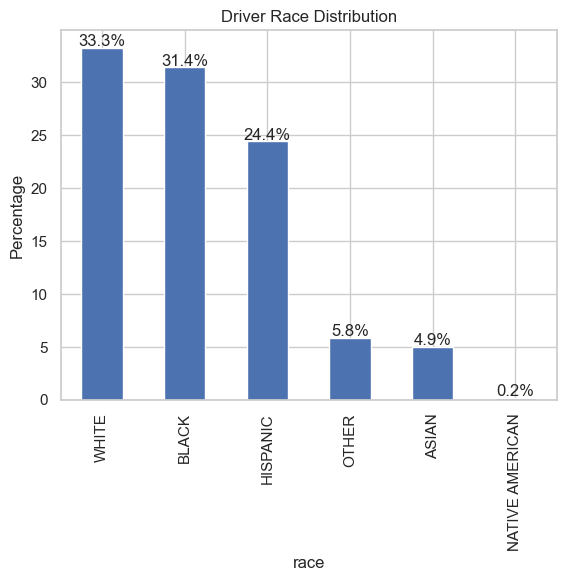

In [34]:
race_pct = traffic_df['race'].value_counts(normalize=True)*100

ax = race_pct.plot(kind='bar')

for i,v in enumerate(race_pct):
    ax.text(i, v+0.2, f'{v:.1f}%', ha='center')

plt.ylabel("Percentage")
plt.title("Driver Race Distribution")
plt.show()

- White drivers represent the largest proportion of traffic stops (33%), followed by Black drivers (31%) and Hispanic drivers (24%). 
- Other racial groups constitute smaller proportions.

- Gender Distribution

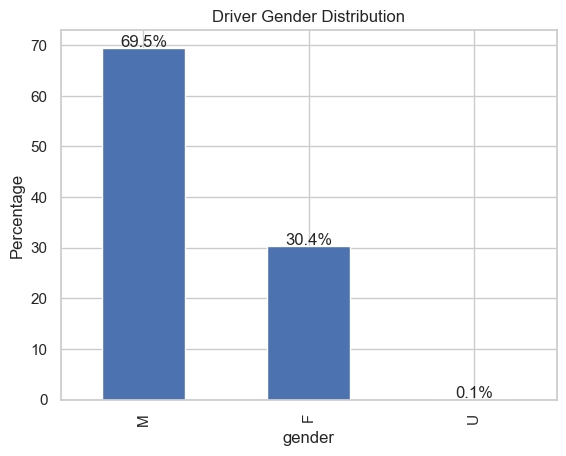

In [35]:
gender_pct = traffic_df['gender'].value_counts(normalize=True)*100
gender_pct
ax = gender_pct.plot(kind='bar')

for i,v in enumerate(gender_pct):
    ax.text(i, v+0.2, f'{v:.1f}%', ha='center')

plt.ylabel("Percentage")
plt.title("Driver Gender Distribution")
plt.show()

- Male drivers account for approximately 69% of stops, while female drivers account for 30%.

- Driver City Distribution

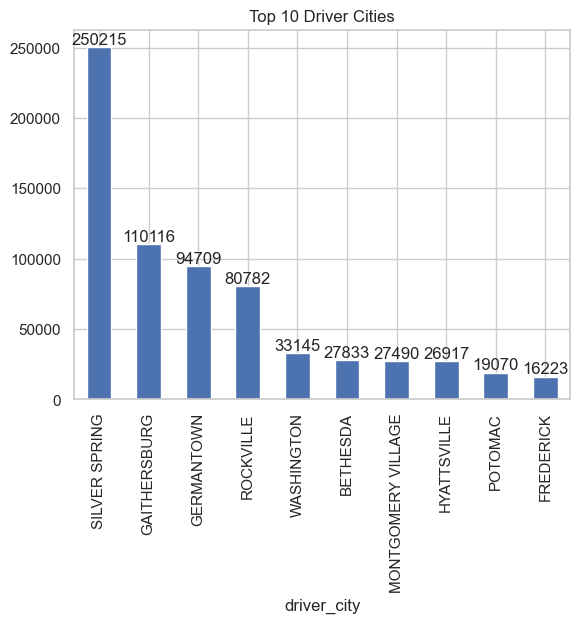

In [36]:
top_city = traffic_df['driver_city'].value_counts().head(10)

ax = top_city.plot(kind='bar')

for i,v in enumerate(top_city):
    ax.text(i, v+2000, f'{v}', ha='center')

plt.title("Top 10 Driver Cities")
plt.show()

- The majority of drivers stopped come from Silver Spring, followed by Gaithersburg and Germantown.

- Driver State

In [37]:
state_pct = traffic_df['driver_state'].value_counts(normalize=True)*100
state_pct.head(10)

driver_state
MD    90.782468
DC     3.314524
VA     3.030040
PA     0.493626
FL     0.291827
NY     0.261404
WV     0.223639
NC     0.205137
CA     0.135518
TX     0.129892
Name: proportion, dtype: float64

- The vast majority of drivers (about 91%) are from Maryland, while neighboring states DC and Virginia contribute smaller proportions.

- Driving License state

In [38]:
dl_pct = traffic_df['dl_state'].value_counts(normalize=True) * 100
dl_pct.head(10)

dl_state
MD    86.625035
DC     3.307354
VA     3.233768
XX     2.198508
PA     0.598422
FL     0.528940
NY     0.423381
NC     0.325744
CA     0.287185
TX     0.256835
Name: proportion, dtype: float64

- The dl_state column contains 23,035 records labeled "XX", which likely represent missing or unidentified driver license states. 
- This should be treated as a data quality issue.

- The majority of drivers involved in traffic stops hold Maryland driver licenses (86%), which is expected since the dataset originates from Montgomery County, Maryland.
- A small proportion of drivers have licenses from neighboring states such as DC and Virginia.
- Approximately 2% of records contain "XX" as the license state, indicating possible missing or unknown values.

##### Commercial License, Hazmat, Commercial vehicle, Alcohol, Work zone

In [39]:
context_cols = ['commercial_license', 'hazmat', 'commercial_vehicle', 'alcohol', 'work_zone']

# Show counts for each column
for col in context_cols:
    print(f"=== {col} value counts ===")
    print(traffic_df[col].value_counts(dropna=False))
    print("\n")

=== commercial_license value counts ===
commercial_license
No     1016347
Yes      32228
Name: count, dtype: int64


=== hazmat value counts ===
hazmat
No     1048512
Yes         63
Name: count, dtype: int64


=== commercial_vehicle value counts ===
commercial_vehicle
No     1045673
Yes       2902
Name: count, dtype: int64


=== alcohol value counts ===
alcohol
No     1046088
Yes       2487
Name: count, dtype: int64


=== work_zone value counts ===
work_zone
No     1048247
Yes        328
Name: count, dtype: int64




- Insights
    + Commercial License
        * No: 1,016,347 (~97%)
        * Yes: 32,228 (~3%)
        * Most drivers are private drivers. Only a small proportion are commercial license holders, which makes sense since most stops involve private vehicles.
    + HAZMAT
        * Yes: 63 (<0.01%)
        * Extremely rare; only a handful of vehicles carry hazardous materials. Could be important for risk-prioritized inspections.
    + Commercial Vehicle
        * Yes: 2,902 (~0.3%)
        * Only a small fraction of stops involve commercial vehicles; these are likely trucks, buses, or service vehicles.
    + Alcohol
        * Yes: 2,487 (~0.2%)
        * Alcohol-related stops are rare but critical for accident analysis and DUI monitoring.
    + Work Zone
        * Yes: 328 (~0.03%)
        * Very few violations occur in work zones, but these can be high-risk areas for accidents.
    + Can be stored as binary categorical (Yes/No) or converted to numeric flags (0/1) for EDA and dashboard visualizations.
    + Useful for filtering or analyzing high-risk violation patterns (e.g., alcohol, HAZMAT, commercial vehicles, or work zones).
    

In [40]:
pd.crosstab(traffic_df['accident'], traffic_df['alcohol'])

alcohol,No,Yes
accident,,
No,995955,2287
Yes,50133,200


In [41]:
pd.crosstab(traffic_df['accident'], traffic_df['commercial_vehicle'])

commercial_vehicle,No,Yes
accident,,
No,995456,2786
Yes,50217,116


In [42]:
risk_factors=traffic_df.groupby('accident')[['alcohol','commercial_vehicle']].apply(lambda x: (x=='Yes').mean()*100)

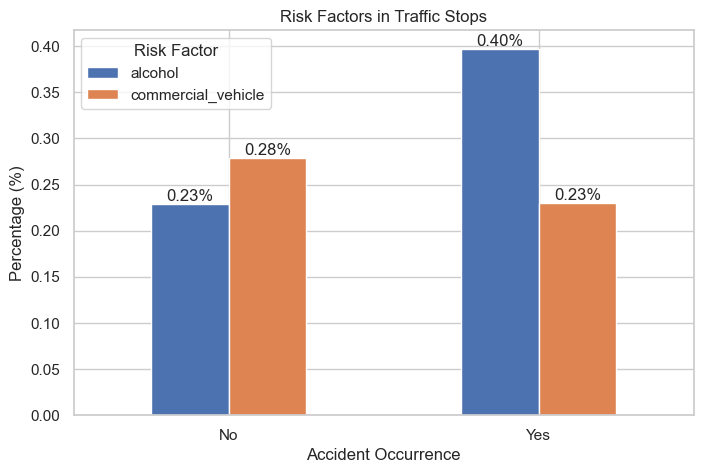

In [43]:
# Plot
ax=risk_factors.plot(kind='bar', figsize=(8,5))

plt.title("Risk Factors in Traffic Stops")
plt.ylabel("Percentage (%)")
plt.xlabel("Accident Occurrence")
# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
plt.xticks(rotation=0)
plt.legend(title="Risk Factor")
plt.show()

+ Alcohol involvement shows a higher percentage in accident cases, indicating that alcohol consumption may increase accident risk.
+ Commercial vehicles show a slightly lower percentage in accidents, suggesting commercial drivers may follow stricter safety practices.
+ Overall, alcohol appears to be a more influential factor in accidents compared to commercial vehicle status

##### Vehicle Type, Year, Make, Model, Color

In [44]:
vehicle_cols = ['vehicle_type', 'year', 'make', 'model', 'color']

# Show counts for each column
for col in vehicle_cols:
    print(f"=== {col} value counts ===")
    print(traffic_df[col].value_counts(dropna=False))
    print("\n")

=== vehicle_type value counts ===
vehicle_type
02 - Automobile              903541
05 - Light Duty Truck         66479
28 - Other                    27777
03 - Station Wagon            17174
01 - Motorcycle               10792
06 - Heavy Duty Truck          8210
29 - Unknown                   5990
08 - Recreational Vehicle      3170
19 - Moped                     1606
07 - Truck/Road Tractor         981
20 - Commercial Rig             644
04 - Limousine                  609
25 - Utility Trailer            499
10 - Transit Bus                432
12 - School Bus                 284
27 - Farm Equipment             110
26 - Boat Trailer                57
09 - Farm Vehicle                47
11 - Cross Country Bus           39
21 - Tandem Trailer              22
23 - Travel/Home Trailer         20
22 - Mobile Home                 18
18 - Police(Non-Emerg)           15
13 - Ambulance(Emerg)            14
15 - Fire(Emerg)                 12
24 - Camper                      11
14 - Ambulance(No

- Vehicle Type:
    - Most common types:
        + Automobile → 903,541 (≈86% of stops)
        + Light Duty Truck → 66,479
        + Other → 27,777

    - Low-frequency / rare types:
       + These are very small counts (<1000 each) and could be grouped into “Other Specialized Vehicles” for dashboards:
       + Emergency vehicles (Police, Fire, Ambulance)
       + Trailers, farm vehicles, RVs, buses
    - Unknown / misc:
       + Unknown → 5,990 → indicates missing/unclear vehicle type
       + Other → 27,777 → likely miscellaneous types
    - Split into Code + Category if useful.
    - Standardize spaces around hyphens.


- Vehicle Year:
    + Most frequent years:
        * 005–2013 dominate the dataset (~500k+ entries each).
        * Makes sense: most vehicles on the road are recent.
    + Outliers / invalid values:
        *   Very low numbers: 5, 9 → obviously invalid for a vehicle year.
        * Very high numbers: 2483, 6247, 4706 → clearly erroneous.
    + Total unique values: 
        * 286 → indicates some bad/missing data encoded as weird numbers.
    + Data profiling / cleaning suggestions:
        + Filter plausible years: Typically 1900 → current year+1.
        + Replace invalid values with NaN or Unknown.
        + Optionally create decade bins for dashboards
    + Convert to numeric.
    + Remove impossible years (<1960 or >2025).
    + Check for nulls.

- Make:
    + Standardize common typos (TOYT → TOYOTA, CHV → CHEVROLET, etc.)
    + Clean spacing.
- Model:
    + Standardize case (upper/lower).
    + Remove cryptic abbreviations if needed.
    + Standardize common typos (TOYT → TOYOTA, CHV → CHEVROLET, etc.)
- Color:
    + Standardize colors (BLACK vs Black vs BLK).
    + Map uncommon shades to the closest standard color.
    + Standardize trims: e.g., CIVIC LX, CIVIC EX → map to CIVIC if analysis is at model-level
    + Handle ambiguous codes (4S, TK) by checking against make for clarity
    + Rare/single-entry models can be grouped as Other for visualization purposes



### 4.7 Violation / Charge Table
- (description, violation_type, charge, article, search_arrest_reason)

- Description

In [45]:
traffic_df['description'].value_counts().head(10)

description
DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC CONTROL DEVICE INSTRUCTIONS                           70435
FAILURE TO DISPLAY REGISTRATION CARD UPON DEMAND BY POLICE OFFICER                                   38406
FAILURE OF INDIVIDUAL DRIVING ON HIGHWAY TO DISPLAY LICENSE TO UNIFORMED POLICE ON DEMAND            36029
PERSON DRIVING MOTOR VEHICLE ON HIGHWAY OR PUBLIC USE PROPERTY ON SUSPENDED LICENSE AND PRIVILEGE    34475
DRIVING VEHICLE ON HIGHWAY WITH SUSPENDED REGISTRATION                                               30001
DRIVER USING HANDS TO USE HANDHELD TELEPHONE WHILEMOTOR VEHICLE IS IN MOTION                         24932
DRIVING VEHICLE WHILE UNDER THE INFLUENCE OF ALCOHOL                                                 24285
DRIVING MOTOR VEHICLE ON HIGHWAY WITHOUT REQUIRED LICENSE AND AUTHORIZATION                          24188
DISPLAYING EXPIRED REGISTRATION PLATE ISSUED BY ANY STATE                                            24067
NEGLIGENT DRIVING VEHICLE

- Column contains textual descriptions of each traffic violation.
- Some descriptions may be very specific or long, leading to high cardinality (many unique values).

- Insights & Implications:
    + Missing values: Only 9 rows missing → negligible, can fill with 'Unknown' or leave as-is.
    + High cardinality → cannot directly use in modeling without encoding or grouping.
    + EDA / visualization:
        + Count of most frequent violations.
        + Top violation categories by district, time, or demographics.
    + Next Step (Cleaning / Preprocessing):
        + Standardize textual descriptions:
        + Strip whitespace, remove unnecessary punctuation.
        + Map similar descriptions into broader categories (Speeding, Signal Violation, Seatbelt, etc.)
        + Use description together with charge and violation_type to generate a categorical summary of violation types.

- Violation Type

In [46]:
traffic_df['violation_type'].value_counts()

violation_type
Citation    849082
Warning     189601
ESERO         9803
SERO            89
Name: count, dtype: int64

- Standardize casing and remove whitespace
- Check rare codes (ESERO, SERO)
    + Investigate their meaning in the data dictionary.
    + If they are valid but rare, keep them as-is.
    + If they are typos, correct to Citation or Warning.
    + Uniform capitalization.
    + Correct inconsistencies (e.g., ‘Citation’, ‘citation’).


- charge

In [47]:
traffic_df['charge'].value_counts()

charge
21-801.1         171071
21-201(a1)        70435
13-409(b)         38627
16-112(c)         36025
16-303(c)         35451
                  ...  
13-620(d)             1
11-393.20(5a)         1
22-228(b)             1
11-393.53             1
23-302                1
Name: count, Length: 1048, dtype: int64

- Standardize formatting
- Handle blanks / nulls
- Reduce cardinality for analysis
- Keep as string.
- Handle multiple entries per stop (your dataset repeats rows with the same SeqID but different charges).


- Article

In [48]:
traffic_df['article'].value_counts()

article
Transportation Article    1032890
Maryland Rules               5757
BR                             25
TG                              6
0                               3
1A                              2
Name: count, dtype: int64

- Distribution:
    + Heavily dominated by Transportation Article.
    + Minor categories (Maryland Rules) appear mostly for unusual violations.
    + Tiny categories (BR, TG, numeric codes like 0, 1A) are likely data entry errors.
- Relationship with Other Columns:
    + Closely linked with charge and violation_type.
    + Can be used to group charges in dashboards (e.g., “All Transportation Article violations”).
- Standardize text
- Handle rare / erroneous values
- Check if every charge maps to a correct article_cleaned.
- This prevents mismatches between charge and its source article.
- Standardize text.
- Fill missing values where pattern repeats.


- Search Arrest Reason
    +  Legal code for arrest if applicable.

In [49]:
traffic_df['search_arrest_reason'].value_counts()

search_arrest_reason
Stop         36753
Search        7108
Other         6211
Warrant       2616
Traffic         27
DUI             13
Marihuana        5
DWI              2
Name: count, dtype: int64

- Most arrests happen because of serious traffic violations or license issues discovered during the stop, not because of a search.
- A portion of arrests happen after illegal items are discovered during a search.
- Some drivers are arrested because they already have active warrants.
- They should likely be grouped into broader categories.

| Original  | Clean Category |
| --------- | -------------- |
| Stop      | Stop           |
| Search    | Search         |
| Warrant   | Warrant        |
| Other     | Other          |
| Traffic   | Stop           |
| DUI       | Other          |
| DWI       | Other          |
| Marihuana | Search         |



### 4.8 Search & Enforcement Columns
- (search_conducted, search_disposition, search_outcome, search_reason, search_reason_for_stop, search_type,search_arrest_reason, arrest_type)

- Search Conducted
    -  Whether a search occurred.

In [50]:
traffic_df['search_conducted'].value_counts()

search_conducted
No     524852
Yes     69983
Name: count, dtype: int64

In [51]:
traffic_df['search_conducted'].isnull().sum()

np.int64(453740)

- Inspect the blank/missing rows
- Confirm by checking for any searches recorded in blanks
- Fill blanks after confirmation

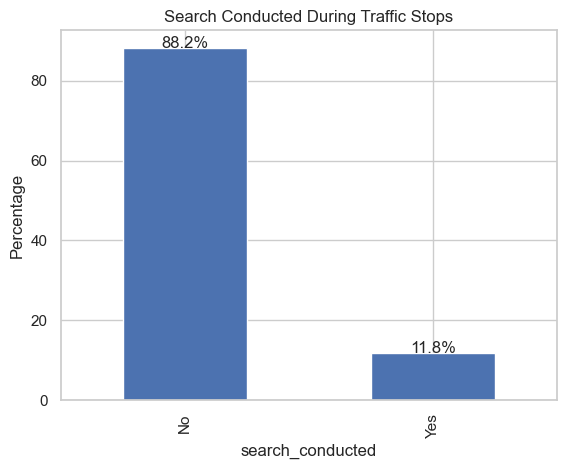

In [52]:
search_pct = traffic_df['search_conducted'].value_counts(normalize=True) * 100
ax = search_pct.plot(kind='bar')

for i,v in enumerate(search_pct):
    ax.text(i, v+0.1, f'{v:.1f}%', ha='center')

plt.title("Search Conducted During Traffic Stops")
plt.ylabel("Percentage")
plt.show()


- Insights
    + Most traffic stops do not result in a search, indicating searches are relatively rare events.

- Search Disposition
    +  Outcome of search (e.g., “Citation”, “Warning”).

In [53]:
traffic_df['search_disposition'].value_counts()

search_disposition
Nothing                    31260
Contraband Only            15452
Property Only              13060
Contraband and Property    10195
DUI                           12
marijuana                      3
nothing                        1
Name: count, dtype: int64

In [54]:
traffic_df['search_disposition'].isnull().sum()

np.int64(978592)

- Insights
    + There’s a capitalization inconsistency: "Nothing" vs "nothing".
    + Extremely low-frequency values like "DUI" and "marijuana" might be typos or rare cases, which could be grouped into “Other” if needed.
    + Many blanks → treat as “Not Applicable”.

- Search Outcome
    +  Specific result of search (contraband found, nothing found, etc.).

In [55]:
traffic_df['search_outcome'].value_counts()

search_outcome
Citation              428401
Warning                88931
Arrest                 53537
SERO                    4882
Recovered Evidence         3
Name: count, dtype: int64

In [56]:
traffic_df['search_outcome'].isnull().sum()

np.int64(472821)

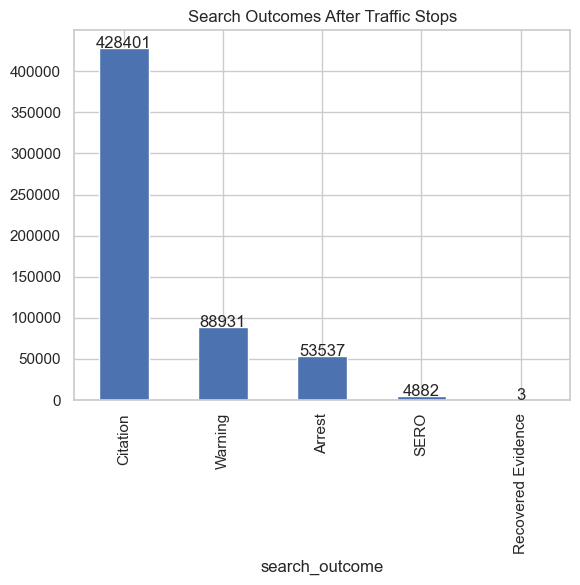

In [57]:
top_outcome = traffic_df['search_outcome'].value_counts()

ax = top_outcome.plot(kind='bar')

for i,v in enumerate(top_outcome):
    ax.text(i, v+500, str(v), ha='center')

plt.title("Search Outcomes After Traffic Stops")
plt.show()

- Standardize values.
- Replace empty strings with “NA”.


- Search Reason
    -  Why did the officer initiate a search?

In [58]:
traffic_df['search_reason'].value_counts()

search_reason
Incident to Arrest        46934
Probable Cause            12849
Consensual                 7794
K-9                        1013
Other                       933
Exigent Circumstances       452
Probable Cause for CDS        4
Arrest/Tow                    3
plain view marijuana          1
Name: count, dtype: int64

- Most searches occur after an arrest (Incident to Arrest).
- Probable Cause searches are the second most common.
- Consensual searches also represent a notable portion.
- K-9 searches are rare (~1k).
- Exigent circumstances are very rare

| Original               | Cleaned               |
| ---------------------- | --------------------- |
| Incident to Arrest     | Incident to Arrest    |
| Probable Cause         | Probable Cause        |
| Probable Cause for CDS | Probable Cause        |
| plain view marijuana   | Probable Cause        |
| Consensual             | Consensual            |
| K-9                    | K-9                   |
| Exigent Circumstances  | Exigent Circumstances |
| Arrest/Tow             | Other                 |
| Other                  | Other                 |


- Search reason For Stop
    +  Legal code describing stop justification.

In [59]:
traffic_df['search_reason_for_stop'].value_counts().head(10)

search_reason_for_stop
21-201(a1)       70497
21-801.1         43863
13-411(f)        27523
13-401(h)        25399
21-1124.2(d2)    24026
21-707(a)        23117
16-303(c)        20098
21-801(b)        19889
21-202(h1)       13498
22-412.3(b)      12709
Name: count, dtype: int64

- contains legal traffic codes 
- Standardize codes (many numeric codes like 17-107(a1)).
- Traffic codes can be grouped by prefix:
| Prefix | Category                  |
| ------ | ------------------------- |
| 21     | Driving violations        |
| 13     | Registration violations   |
| 16     | License violations        |
| 22     | Equipment violations      |
| 23     | Vehicle safety violations |

- Keep original legal codes.
- Create a grouped category column based on code prefix.
- Several invalid or inconsistent values exist
- They should be categorized as "Unknown" or "Other" during data cleaning.
- The column is highly skewed.
- A small number of codes account for most stops.

- Search Type
    -  Type of search (vehicle, person, voluntary consent, etc.)

In [60]:
traffic_df['search_type'].value_counts()

search_type
Both                 52328
Person                9594
Property              8046
car                      4
Search Incidental        3
PC                       1
Name: count, dtype: int64

In [61]:
traffic_df['search_type'].isnull().sum()

np.int64(978599)

- The majority of searches involve both the driver and the vehicle.
- Standardize casing
- Fix inconsistent labels
- Map rare values to valid categories (Both, Person, Property, Unknown)
- Many blanks → treat as “Not applicable”.


- Search Rate by Race

In [62]:
pd.crosstab(traffic_df['race'], traffic_df['search_conducted'], normalize='index')*100

search_conducted,No,Yes
race,,
ASIAN,92.897094,7.102906
BLACK,86.432045,13.567955
HISPANIC,85.761771,14.238229
NATIVE AMERICAN,92.934331,7.065669
OTHER,94.599183,5.400817
WHITE,90.519444,9.480556


- Arrest Rate by Gender

In [63]:
- pd.crosstab(traffic_df['gender'], traffic_df['arrest_type'], normalize='index')*100

arrest_type,A - Marked Patrol,B - Unmarked Patrol,C - Marked VASCAR,D - Unmarked VASCAR,E - Marked Stationary Radar,F - Unmarked Stationary Radar,G - Marked Moving Radar (Stationary),H - Unmarked Moving Radar (Stationary),I - Marked Moving Radar (Moving),J - Unmarked Moving Radar (Moving),K - Aircraft Assist,L - Motorcycle,M - Marked (Off-Duty),N - Unmarked (Off-Duty),O - Foot Patrol,P - Mounted Patrol,Q - Marked Laser,R - Unmarked Laser,S - License Plate Recognition
gender,,,,,,,,,,,,,,,,,,,
F,-70.234809,-5.037452,-0.023839,-0.023211,-1.059245,-0.113547,-1.940956,-0.100059,-0.324329,-0.037326,-0.003137,-1.557030,-0.228975,-0.015997,-1.412431,-0.015370,-15.400926,-0.809568,-1.661794
M,-76.936335,-5.466694,-0.033346,-0.021270,-0.743219,-0.066418,-1.167249,-0.082473,-0.278433,-0.047480,-0.003293,-1.185500,-0.185942,-0.024564,-0.999833,-0.013037,-10.801376,-0.610795,-1.332744
U,-93.467819,-4.418828,-0.000000,-0.000000,-0.096061,-0.000000,-0.000000,-0.096061,-0.000000,-0.000000,-0.000000,-0.480307,-0.096061,-0.000000,-0.096061,-0.000000,-1.152738,-0.000000,-0.096061


- Arrest Type
    +  Type of enforcement — “A - Marked Patrol”, “B - Unmarked”, etc.

In [64]:
traffic_df['arrest_type'].value_counts()

arrest_type
A - Marked Patrol                         785542
Q - Marked Laser                          127824
B - Unmarked Patrol                        55943
S - License Plate Recognition              15011
G - Marked Moving Radar (Stationary)       14694
L - Motorcycle                             13608
O - Foot Patrol                            11790
E - Marked Stationary Radar                 8794
R - Unmarked Laser                          7032
I - Marked Moving Radar (Moving)            3063
M - Marked (Off-Duty)                       2086
H - Unmarked Moving Radar (Stationary)       921
F - Unmarked Stationary Radar                846
J - Unmarked Moving Radar (Moving)           465
C - Marked VASCAR                            319
N - Unmarked (Off-Duty)                      230
D - Unmarked VASCAR                          229
P - Mounted Patrol                           144
K - Aircraft Assist                           34
Name: count, dtype: int64

- The vast majority of traffic stops are conducted by regular marked police vehicles.
- Speed detection technologies contribute significantly to traffic violation detection.
- Police also use unmarked vehicles for enforcement, though much less frequently than marked patrols.
- Modern technologies such as automatic license plate readers (ALPR) are used in enforcement.
- Standardize categories.
- Split Code + Description if needed.
| arrest_code | arrest_method |
| ----------- | ------------- |
| A           | Marked Patrol |
| Q           | Marked Laser  |


In [65]:
duplicate_count=traffic_df.duplicated().sum()
print(f"=== Duplicate Rows ===\n{duplicate_count} duplicates found")

=== Duplicate Rows ===
1718 duplicates found


- Duplicate records may arise from data ingestion errors or repeated entries. 
- Identifying duplicates is important before performing further analysis.

### 4.9 Optional Visual Profiling

- Missing values heatmap:

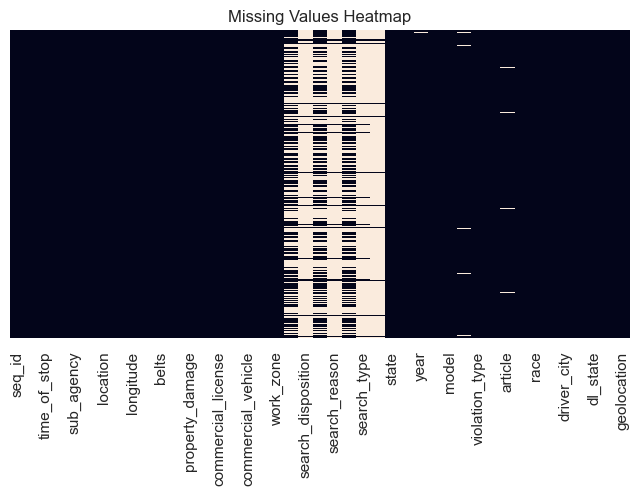

In [66]:
plt.figure(figsize=(8,4))
sns.heatmap(traffic_df.isnull().sample(5000),cbar=False,yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

- Top Categories for Key Categorical Variables

    + To understand the distribution of important categorical variables, the top 10 most frequent values were visualized using bar charts.

    + The following variables were analyzed:
        - Violation Type
        - Driver Race
        - Driver Gender
        - Vehicle Type
        - Vehicle Make

    + This helps identify dominant categories and potential patterns within the traffic violation dataset.

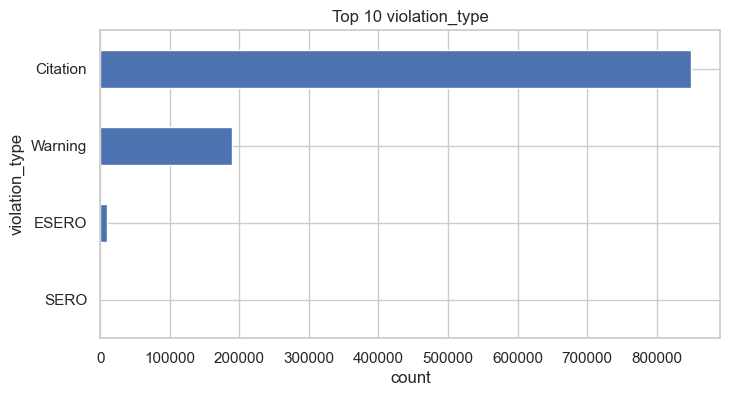

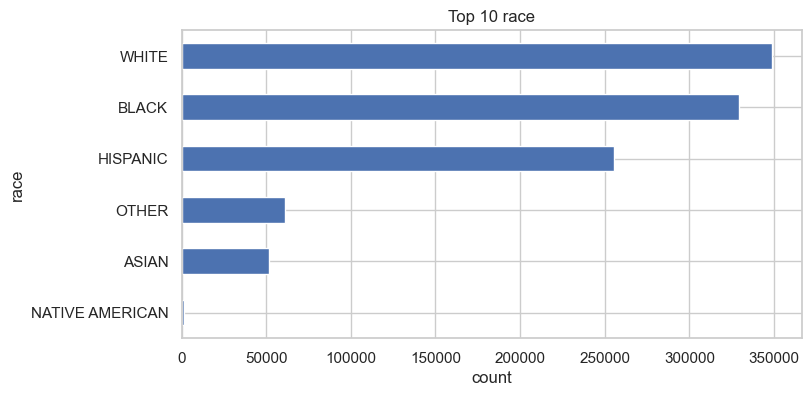

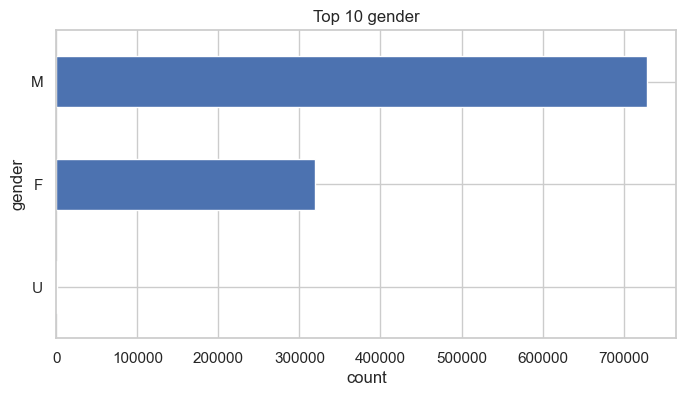

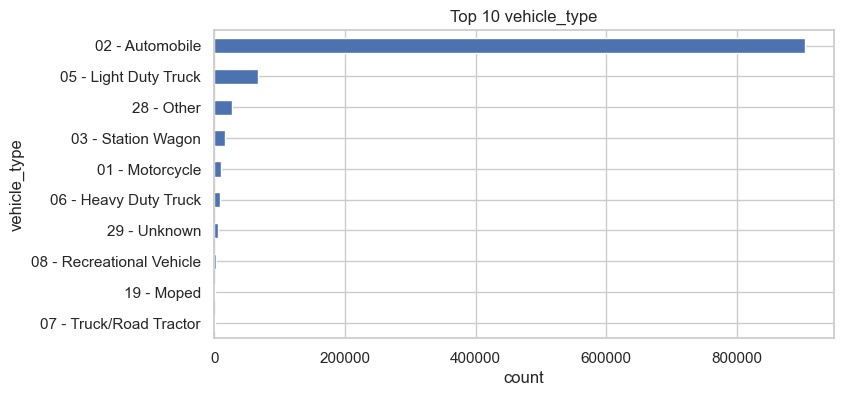

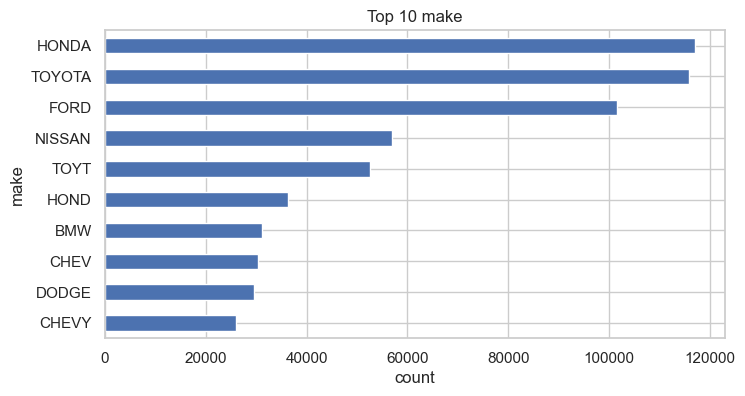

In [67]:
top_cols = ['violation_type', 'race', 'gender', 'vehicle_type', 'make']
for col in top_cols:
    plt.figure(figsize=(8,4))
    traffic_df[col].value_counts().head(10).sort_values().plot(kind='barh',title=f"Top 10 {col}")
    plt.xlabel("count")
    plt.ylabel(col)
    plt.show()


In [68]:
traffic_df.to_csv("../data/traffic_v1_df.csv", index=False)